In [5]:
import zarr
import numpy as np
import os
HARPS_DATA = '/Users/mjablons/code/turbo/test.zarr/synthesized_spectra.zarr/'

In [6]:
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

In [7]:
o = zarr.open_group(HARPS_DATA)
o.tree()

/
├── continuum (100, 313001) float32
├── flux (100, 313001) float32
├── global_index (100,) int64
├── model_id (100,) uint64
├── param_names (21,) <U32
├── params (100, 21) float32
├── physics_hash (1,) <U72
├── provenance
│   ├── atmosphere_manifest.json (1,) StringDType()
│   ├── canonical_config.yaml (1,) StringDType()
│   ├── environment.txt (1,) StringDType()
│   ├── input_config.json (1,) StringDType()
│   ├── linelist_manifest.json (1,) StringDType()
│   ├── software_manifest.json (1,) StringDType()
│   └── synthesis_config.yaml (1,) StringDType()
├── schema_version (1,) <U16
└── wavelength (313001,) float32

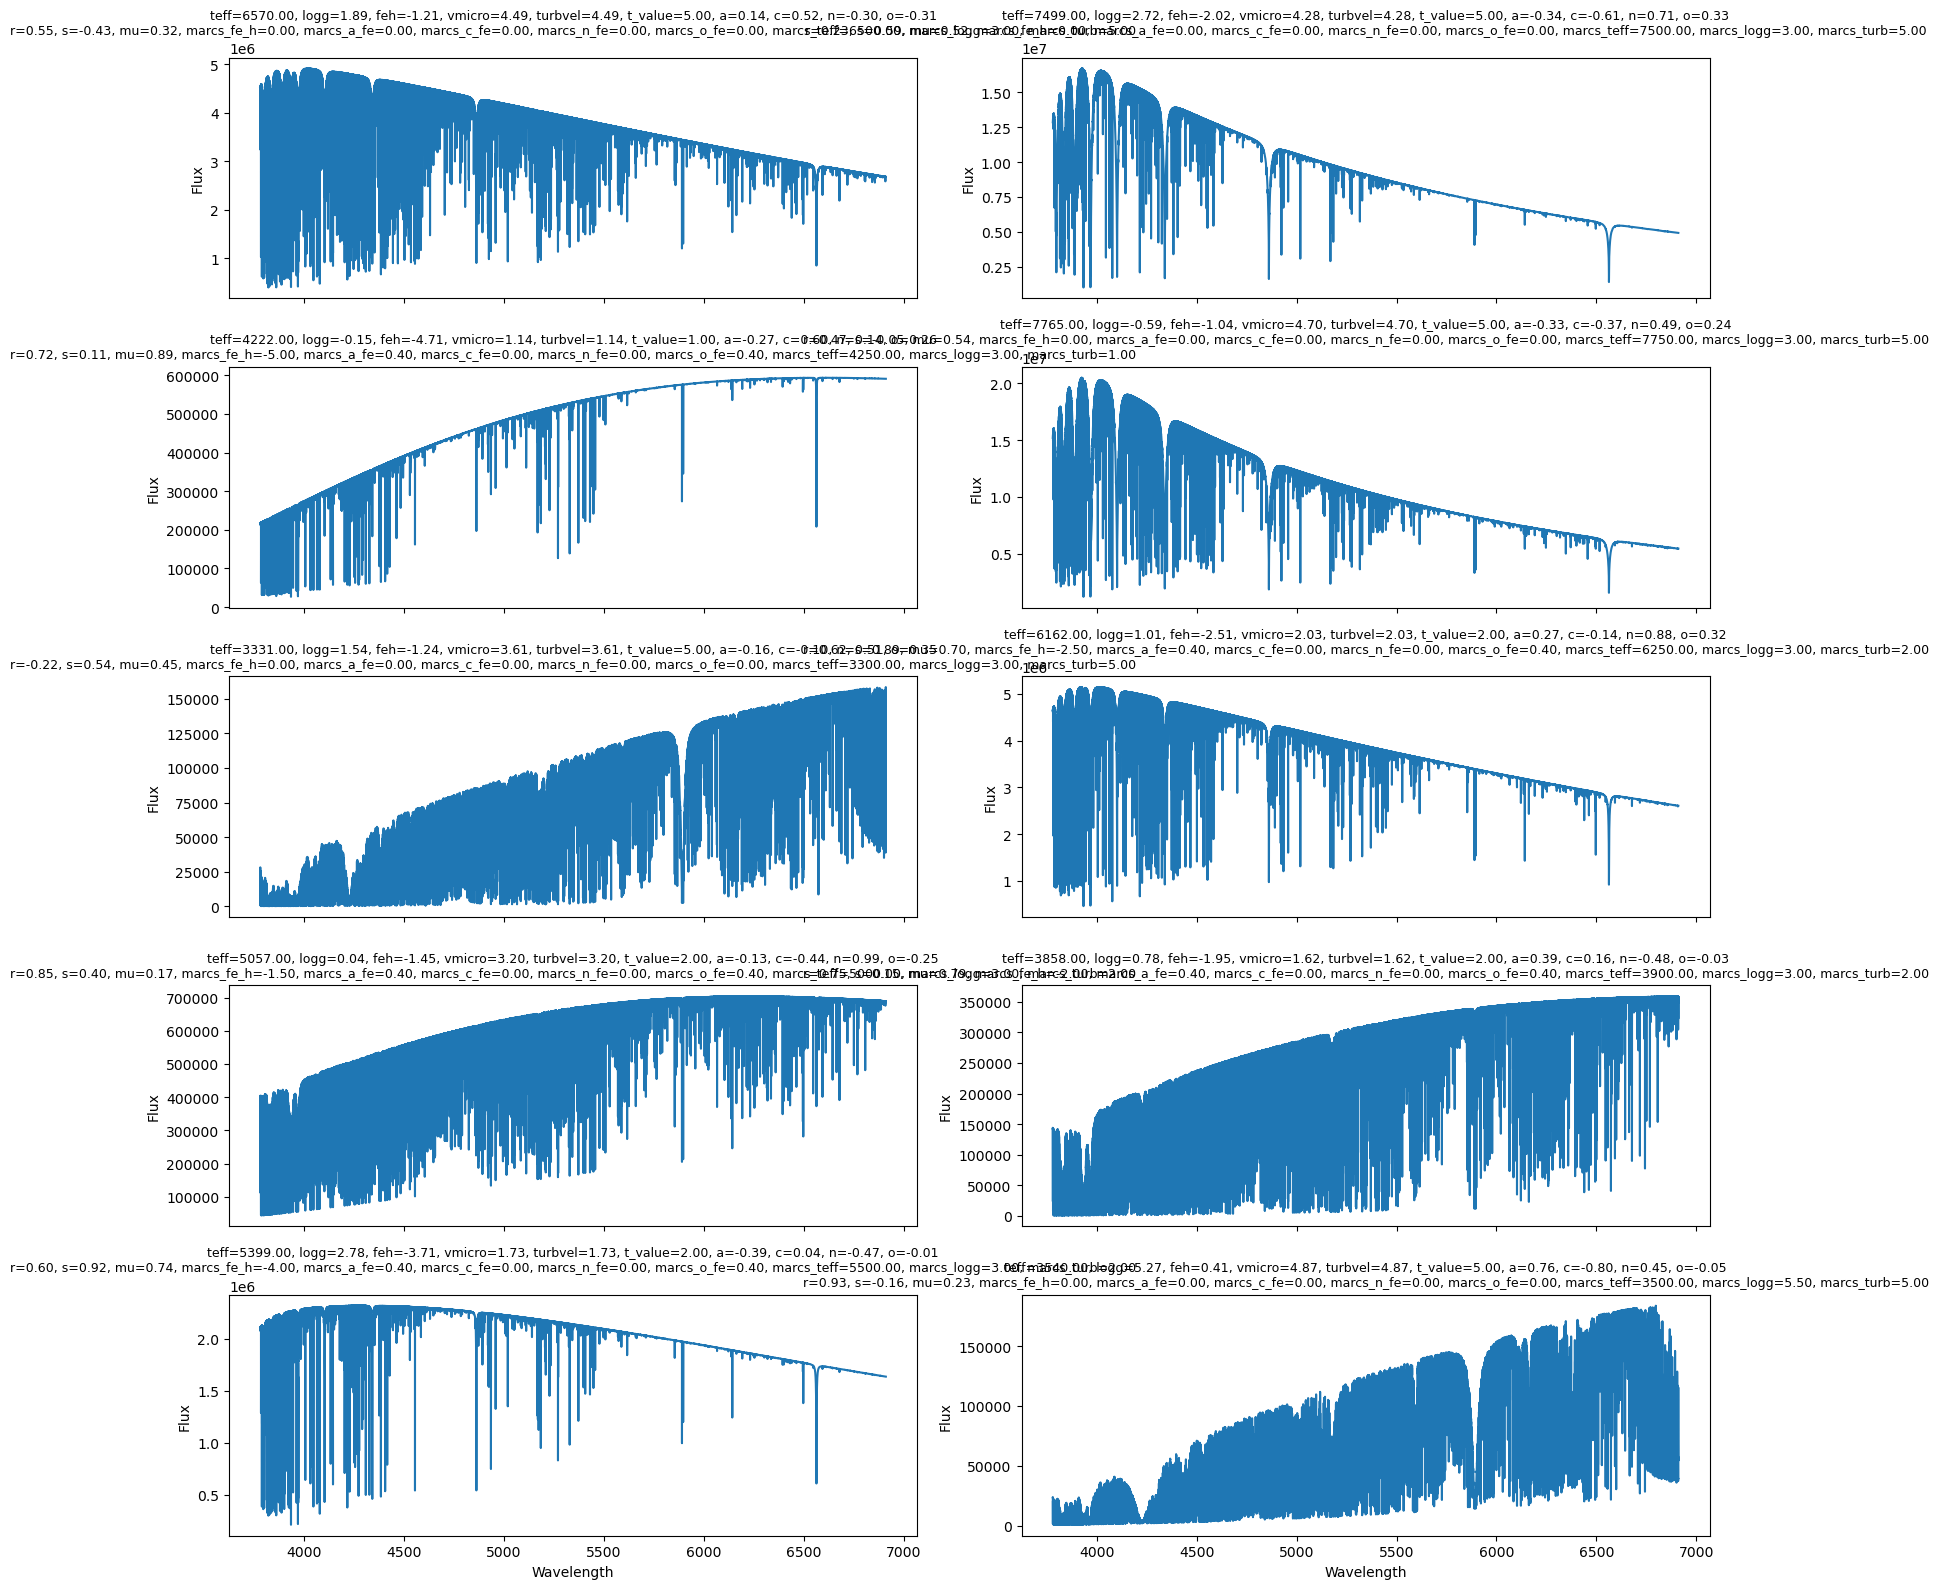

In [8]:
param_names = o['param_names'][:]
wavelength = o['wavelength'][:]
fig, axes = plt.subplots(5, 2, figsize=(16, 16), sharex=True)
axes = axes.flatten()

for i in range(10):
    params = o['params'][i]
    flux = o['flux'][i]
    pairs = [f'{name}={val:.2f}' for name, val in zip(param_names, params)]
    # Split the title into two roughly equal lines
    split = len(pairs) // 2
    title_str = '\n'.join([', '.join(pairs[:split]), ', '.join(pairs[split:])])
    axes[i].plot(wavelength, flux)
    axes[i].set_title(title_str, fontsize=9)
    axes[i].set_ylabel("Flux")
    if i >= 8:
        axes[i].set_xlabel("Wavelength")

plt.tight_layout()
plt.show()

mu parameter index: 12
Found 1 spectra within 10% of reference parameters (excl. mu) at index 0.


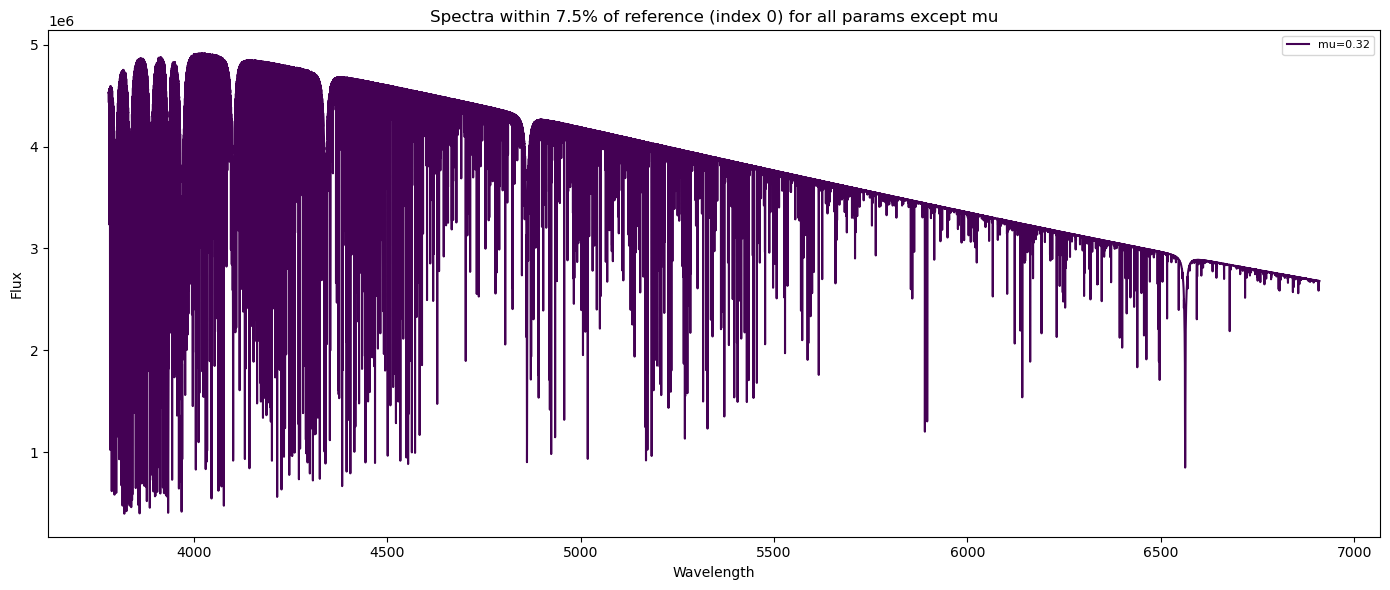

In [9]:
# Let's check dependence on "mu" (usually μ is cosine of angle, often one of the params).
# We'll plot spectra with values within 10% for all parameters except "mu".

# First, find the index of the "mu" parameter:
mu_param_name = None
for name in param_names:
    if name.lower() in ('mu', 'cos_theta', 'cos_angle', 'costheta', 'cos(mu)', 'cosmu'):
        mu_param_name = name
        break

if mu_param_name is None:
    print("Could not find parameter named 'mu' or equivalent. Please check param_names.")
else:
    mu_idx = list(param_names).index(mu_param_name)
    print(f"mu parameter index: {mu_idx}")

    # Load all params
    params_all = o['params'][:]      # shape (N, 13)
    mu_vals = params_all[:, mu_idx]  # all mu values

    # Choose one example as a "reference" value set (besides mu)
    ref_idx = 0
    ref = params_all[ref_idx]
    # Use all parameters except mu for matching
    non_mu_indices = [i for i in range(params_all.shape[1]) if i != mu_idx]
    non_mu_ref = ref[non_mu_indices]

    # Find all spectra where each non-mu parameter is within 10% of ref
    tol_fraction = 0.075  # 10%
    masks = []
    for j, i in enumerate(non_mu_indices):
        ref_val = non_mu_ref[j]
        # Edge case: if ref_val == 0, use absolute tolerance of 10^-3
        if np.abs(ref_val) < 1e-10:
            masks.append(np.abs(params_all[:, i] - ref_val) < 1e-3)
        else:
            masks.append(np.abs(params_all[:, i] - ref_val) < tol_fraction * np.abs(ref_val))
    mask = np.logical_and.reduce(masks)
    candidate_indices = np.where(mask)[0]
    print(f"Found {len(candidate_indices)} spectra within 10% of reference parameters (excl. mu) at index {ref_idx}.")

    # For these, collect their mu values
    sorted_candidates = sorted(candidate_indices, key=lambda idx: params_all[idx, mu_idx])
    mu_samples = [params_all[idx, mu_idx] for idx in sorted_candidates]

    # Plot all matching spectra, color by mu
    plt.figure(figsize=(14, 6))
    cmap = plt.get_cmap("viridis", len(sorted_candidates) if len(sorted_candidates) > 1 else 2)
    for j, idx in enumerate(sorted_candidates):
        flux = o['flux'][idx]
        mu_val = params_all[idx, mu_idx]
        plt.plot(wavelength, flux, label=f"mu={mu_val:.2f}", color=cmap(j/len(sorted_candidates)))
    plt.title(f"Spectra within 7.5% of reference (index {ref_idx}) for all params except mu")
    plt.xlabel("Wavelength")
    plt.ylabel("Flux")
    plt.legend(fontsize=8, loc='best', ncol=2)
    plt.tight_layout()
    plt.show()

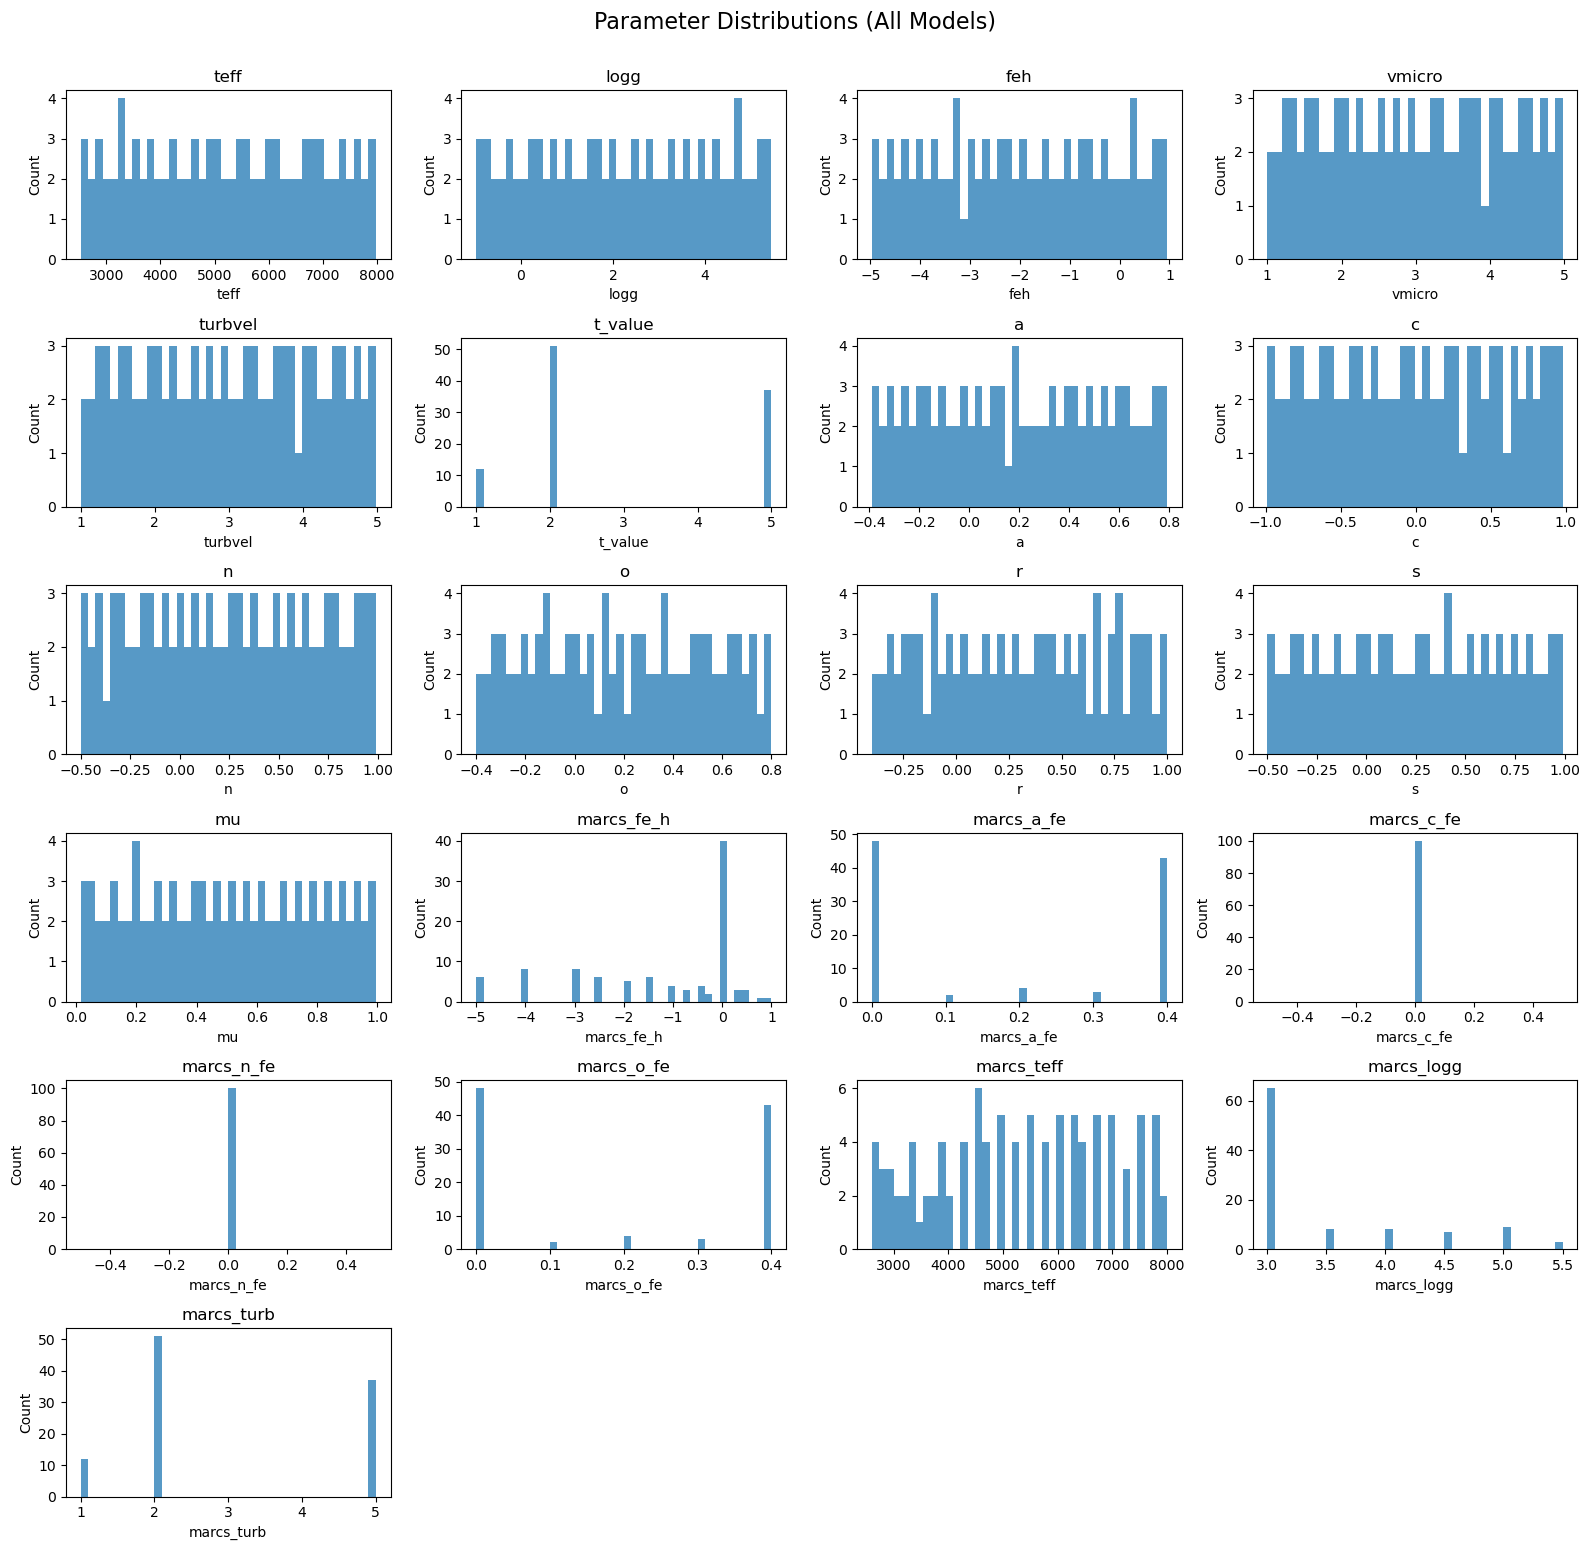

In [10]:
import matplotlib.pyplot as plt

# Plot histograms for all parameters
plt.figure(figsize=(16, 15))
num_params = params_all.shape[1]
cols = 4
rows = (num_params + cols - 1) // cols

for i in range(num_params):
    plt.subplot(rows, cols, i + 1)
    plt.hist(params_all[:, i], bins=40, color='C0', alpha=0.75)
    plt.title(param_names[i])
    plt.xlabel(param_names[i])
    plt.ylabel('Count')
    plt.tight_layout()

plt.suptitle("Parameter Distributions (All Models)", y=1.03, fontsize=16)
plt.show()

param     requested range             MARCS range                   max |snap|   mean |snap|
--------------------------------------------------------------------------------------------
teff      [+2527.000, +7978.000]      [+2600.000, +8000.000]           330.000        58.600
logg      [  -0.972,   +5.440]      [  +3.000,   +5.500]             3.972         1.287
feh       [  -4.972,   +0.950]      [  -5.000,   +1.000]             4.659         0.923
vmicro    [  +1.000,   +4.980]      [  +1.000,   +5.000]             1.490         0.625
a         [  -0.390,   +0.790]      [  +0.000,   +0.400]             0.790         0.318
c         [  -0.990,   +0.980]      [  +0.000,   +0.000]             0.990         0.501
n         [  -0.500,   +0.990]      [  +0.000,   +0.000]             0.990         0.417
o         [  -0.400,   +0.800]      [  +0.000,   +0.400]             0.800         0.344


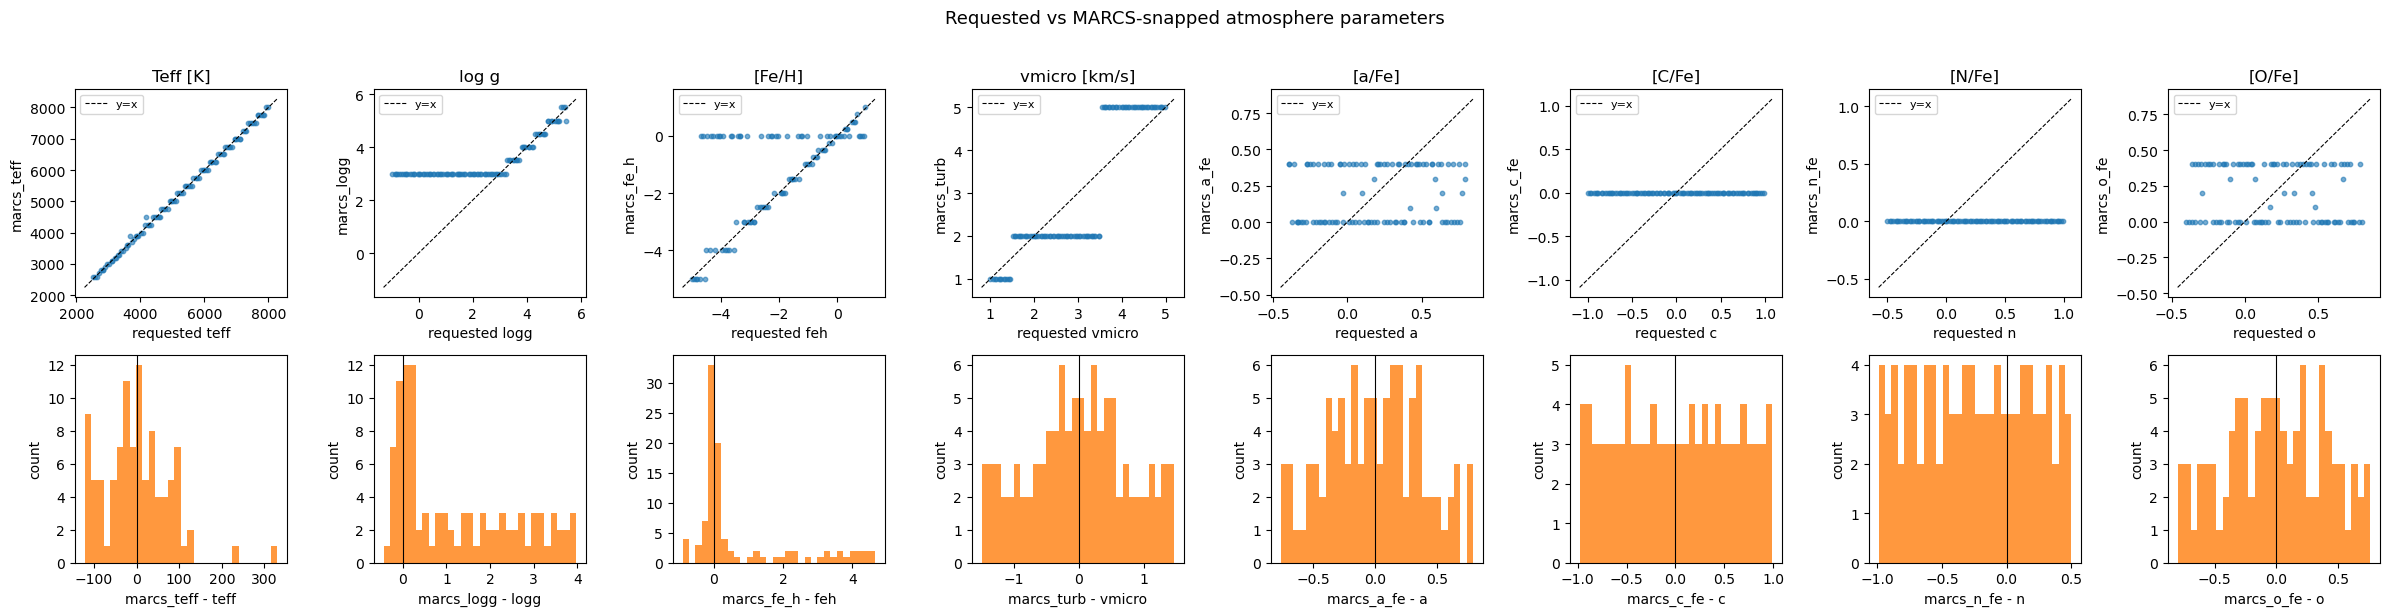


Fraction of requested values outside the MARCS envelope (these get clamped):
  teff     envelope=[+2500.00, +8000.00]  outside: 0/100  (0.0%)
  logg     envelope=[ -1.00,  +5.50]  outside: 0/100  (0.0%)
  feh      envelope=[ -5.00,  +1.00]  outside: 0/100  (0.0%)
  vmicro   envelope=[ +0.00,  +5.00]  outside: 0/100  (0.0%)
  a        envelope=[ +0.00,  +0.40]  outside: 66/100  (66.0%)


In [11]:
# Verify MARCS snap/clip works correctly:
# every requested parameter (teff, logg, feh, a, c, n, o, vmicro) has a stored
# `marcs_*` counterpart that records the value of the *actually-loaded*
# MARCS atmosphere. Plot requested vs snapped and the snap residual so we can
# see how far each row was clamped to the grid edge.

import numpy as np
import matplotlib.pyplot as plt

names = list(param_names)
params_all = o['params'][:]
def col(name):
    return params_all[:, names.index(name)]

# (requested_name, marcs_name, human_label)
pairs = [
    ('teff',   'marcs_teff', 'Teff [K]'),
    ('logg',   'marcs_logg', 'log g'),
    ('feh',    'marcs_fe_h', '[Fe/H]'),
    ('vmicro', 'marcs_turb', 'vmicro [km/s]'),
    ('a',      'marcs_a_fe', '[a/Fe]'),
    ('c',      'marcs_c_fe', '[C/Fe]'),
    ('n',      'marcs_n_fe', '[N/Fe]'),
    ('o',      'marcs_o_fe', '[O/Fe]'),
]
pairs = [p for p in pairs if p[0] in names and p[1] in names]

n = len(pairs)
fig, axes = plt.subplots(2, n, figsize=(3.0 * n, 6), squeeze=False)

print(f"{'param':<10}{'requested range':<28}{'MARCS range':<28}{'max |snap|':>12}{'mean |snap|':>14}")
print('-' * 92)
for j, (req_name, marcs_name, label) in enumerate(pairs):
    req = col(req_name).astype(float)
    snap = col(marcs_name).astype(float)
    diff = snap - req

    ax = axes[0, j]
    ax.scatter(req, snap, s=10, alpha=0.6)
    lo = float(min(req.min(), snap.min()))
    hi = float(max(req.max(), snap.max()))
    pad = 0.05 * (hi - lo) if hi > lo else 0.5
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], 'k--', lw=0.8, label='y=x')
    ax.set_xlabel(f'requested {req_name}')
    ax.set_ylabel(f'{marcs_name}')
    ax.set_title(label)
    ax.legend(fontsize=8, loc='best')

    ax = axes[1, j]
    ax.hist(diff, bins=30, color='C1', alpha=0.8)
    ax.axvline(0, color='k', lw=0.8)
    ax.set_xlabel(f'{marcs_name} - {req_name}')
    ax.set_ylabel('count')

    print(
        f"{req_name:<10}"
        f"[{req.min():>+8.3f}, {req.max():>+8.3f}]      "
        f"[{snap.min():>+8.3f}, {snap.max():>+8.3f}]      "
        f"{np.abs(diff).max():>12.3f}{np.abs(diff).mean():>14.3f}"
    )

plt.suptitle('Requested vs MARCS-snapped atmosphere parameters', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# Highlight rows that were clamped to the MARCS envelope edge (large snap).
# We use the documented MARCS standard-composition envelope from
# scripts/generate_grid.py: teff [2500, 8000], logg [-1, 5.5], feh [-5, 1],
# vmicro [0, 5], plus alpha [0, 0.4] (MARCS only carries alpha-enhanced grids
# at 0.0 and +0.4; C/N are always 0 in MARCS itself).
envelope = {
    'teff':   (2500.0, 8000.0),
    'logg':   (-1.0,    5.5),
    'feh':    (-5.0,    1.0),
    'vmicro': ( 0.0,    5.0),
    'a':      ( 0.0,    0.4),
}
print("\nFraction of requested values outside the MARCS envelope (these get clamped):")
for axis, (lo, hi) in envelope.items():
    if axis not in names:
        continue
    v = col(axis).astype(float)
    n_out = int(np.count_nonzero((v < lo) | (v > hi)))
    print(f"  {axis:<8} envelope=[{lo:>+6.2f}, {hi:>+6.2f}]  outside: {n_out}/{v.size}  ({100*n_out/v.size:.1f}%)")


In [ ]:
# Verify the clamped values are the *closest available* MARCS atmosphere by
# replaying the snap algorithm from scripts/run_turbospectrum.py against the
# on-disk MARCS inventory and comparing to what was stored in the zarr.
#
# Snap algorithm (run_turbospectrum.py: ModelInterpolator.find_nearest_model
# + _nearest_turb_label):
#   1. Scan only plane-parallel atmospheres (filenames starting with "p").
#   2. Pick the turb label whose integer value is closest to requested vmicro
#      (labels "00","01","02","05" -> 0,1,2,5 km/s).
#   3. Restrict to atmospheres with that turb label (fall back to all if empty).
#   4. Pick the atmosphere that minimises
#         ((teff - target)/250)**2
#       + ((logg - target)/0.5)**2
#       + ((feh  - target)/0.5)**2
#      Note: alpha/C/N/O are NOT in the metric — whichever composition the
#      winning (teff,logg,feh,turb) point happens to carry is what gets stored
#      in marcs_a_fe / marcs_c_fe / marcs_n_fe / marcs_o_fe.

import os, re, glob
import numpy as np

PROJECT_ROOT = '/Users/mjablons/code/turbo'
MARCS_CANDIDATES = [
    os.path.join(PROJECT_ROOT, 'input_files/model_atmospheres/1D/marcs_standard_comp/marcs_standard_comp'),
    os.path.join(PROJECT_ROOT, 'input_files/model_atmospheres/1D/marcs_standard_comp'),
]
MARCS_DIR = next((p for p in MARCS_CANDIDATES if os.path.isdir(p)), None)
assert MARCS_DIR is not None, f'MARCS atmosphere directory not found in {MARCS_CANDIDATES}'

MARCS_RE = re.compile(
    r'^p(\d+)_g([+\-]\d+\.\d+)_m0\.0_t(\d+)_st'
    r'_z([+\-]\d+\.\d+)_a([+\-]\d+\.\d+)_c([+\-]\d+\.\d+)_n([+\-]\d+\.\d+)_o([+\-]\d+\.\d+)'
    r'_r([+\-]\d+\.\d+)_s([+\-]\d+\.\d+)\.mod$'
)
records = []
for path in glob.glob(os.path.join(MARCS_DIR, 'p*.mod')):
    m = MARCS_RE.match(os.path.basename(path))
    if not m:
        continue
    records.append({
        'teff':  int(m.group(1)),
        'logg':  float(m.group(2)),
        'turb':  m.group(3),
        'feh':   float(m.group(4)),
        'a_fe':  float(m.group(5)),
        'c_fe':  float(m.group(6)),
        'n_fe':  float(m.group(7)),
        'o_fe':  float(m.group(8)),
    })
print(f'Loaded {len(records)} plane-parallel MARCS atmospheres from {MARCS_DIR}')
turb_labels = sorted({r['turb'] for r in records}, key=lambda s: int(s))
print(f'Available turb labels: {turb_labels}  -> ', {lab: float(lab) for lab in turb_labels})

# Index by turb for speed: arrays per label.
by_turb = {}
for lab in turb_labels:
    grp = [r for r in records if r['turb'] == lab]
    by_turb[lab] = {
        'teff': np.asarray([r['teff'] for r in grp], dtype=float),
        'logg': np.asarray([r['logg'] for r in grp]),
        'feh':  np.asarray([r['feh']  for r in grp]),
        'a_fe': np.asarray([r['a_fe'] for r in grp]),
        'c_fe': np.asarray([r['c_fe'] for r in grp]),
        'n_fe': np.asarray([r['n_fe'] for r in grp]),
        'o_fe': np.asarray([r['o_fe'] for r in grp]),
    }

def nearest_turb_label(vmicro, labels):
    return min(labels, key=lambda lab: (abs(float(lab) - float(vmicro)), int(lab)))

TEFF_SCALE, LOGG_SCALE, FEH_SCALE = 250.0, 0.5, 0.5

def find_nearest(req_teff, req_logg, req_feh, turb_lab):
    g = by_turb.get(turb_lab) or by_turb[nearest_turb_label(0.0, turb_labels)]  # not expected to fall back
    d2 = (
        ((g['teff'] - req_teff) / TEFF_SCALE) ** 2
      + ((g['logg'] - req_logg) / LOGG_SCALE) ** 2
      + ((g['feh']  - req_feh ) / FEH_SCALE ) ** 2
    )
    best = int(np.argmin(d2))
    # All grid points tied with the winner (within float tol) — any of these
    # would be a valid pick under min-with-stable-tiebreak.
    tied_mask = np.isclose(d2, d2[best], rtol=0, atol=1e-12)
    return best, tied_mask, g

# Helpers to read columns by name.
names = list(param_names)
params_all = o['params'][:]
def col(n): return params_all[:, names.index(n)]

req_teff   = col('teff')
req_logg   = col('logg')
req_feh    = col('feh')
req_vmicro = col('vmicro')

stored_marcs_teff = col('marcs_teff')
stored_marcs_logg = col('marcs_logg')
stored_marcs_feh  = col('marcs_fe_h')
stored_marcs_turb = col('marcs_turb')
stored_marcs_a    = col('marcs_a_fe')
stored_marcs_c    = col('marcs_c_fe')
stored_marcs_n    = col('marcs_n_fe')
stored_marcs_o    = col('marcs_o_fe')

n_rows = req_teff.size
disagreements = []
turb_mismatches = 0
nonoptimal = 0       # stored snap has strictly larger distance than the true best
ambiguous_comp = 0   # stored (teff,logg,feh,turb) is optimal but stored a/c/n/o doesn't match any tied grid point

for i in range(n_rows):
    expected_turb = nearest_turb_label(req_vmicro[i], turb_labels)
    if float(expected_turb) != float(stored_marcs_turb[i]):
        turb_mismatches += 1

    # Distance the stored snap actually achieved (using the row's stored turb,
    # which we already know matches the expected turb in this dataset).
    g = by_turb[f'{int(stored_marcs_turb[i]):02d}']
    d2_stored_min_for_stored_point = float(np.min(
        ((g['teff'] - req_teff[i]) / TEFF_SCALE) ** 2
      + ((g['logg'] - req_logg[i]) / LOGG_SCALE) ** 2
      + ((g['feh']  - req_feh[i] ) / FEH_SCALE ) ** 2
    ))
    # Distance of the stored snap point itself
    point_match = (
        (g['teff'] == stored_marcs_teff[i])
      & (np.isclose(g['logg'], stored_marcs_logg[i], atol=1e-6))
      & (np.isclose(g['feh'],  stored_marcs_feh[i],  atol=1e-6))
    )
    if not point_match.any():
        disagreements.append((i, 'stored (teff,logg,feh,turb) not present in inventory'))
        continue
    d2_stored = float(np.min(
        ((stored_marcs_teff[i] - req_teff[i]) / TEFF_SCALE) ** 2
      + ((stored_marcs_logg[i] - req_logg[i]) / LOGG_SCALE) ** 2
      + ((stored_marcs_feh[i]  - req_feh[i] ) / FEH_SCALE ) ** 2
    ))

    if d2_stored > d2_stored_min_for_stored_point + 1e-12:
        nonoptimal += 1
        disagreements.append((
            i,
            f'stored snap suboptimal: d2={d2_stored:.6f} vs best={d2_stored_min_for_stored_point:.6f}'
        ))
        continue

    # The stored (teff,logg,feh,turb) is one of the tied optima. Now check
    # the stored composition matches one of the on-disk atmospheres at that
    # exact (teff,logg,feh,turb) tuple.
    same_point = point_match
    comp_match = (
        np.isclose(g['a_fe'][same_point], stored_marcs_a[i], atol=1e-6)
      & np.isclose(g['c_fe'][same_point], stored_marcs_c[i], atol=1e-6)
      & np.isclose(g['n_fe'][same_point], stored_marcs_n[i], atol=1e-6)
      & np.isclose(g['o_fe'][same_point], stored_marcs_o[i], atol=1e-6)
    )
    if not comp_match.any():
        ambiguous_comp += 1
        disagreements.append((
            i,
            f'stored composition (a={stored_marcs_a[i]}, c={stored_marcs_c[i]}, '
            f'n={stored_marcs_n[i]}, o={stored_marcs_o[i]}) not found at the snapped grid point'
        ))

print()
print(f'Rows checked: {n_rows}')
print(f'  turb-label mismatches:           {turb_mismatches}')
print(f'  suboptimal (teff,logg,feh) snap: {nonoptimal}')
print(f'  composition not on-disk for snap point: {ambiguous_comp}')
print(f'  disagreements total:             {len(disagreements)}')
if disagreements:
    print('\nFirst few disagreements:')
    for idx, msg in disagreements[:5]:
        print(f'  row {idx}: req(teff={req_teff[idx]:.0f}, logg={req_logg[idx]:.2f}, '
              f'feh={req_feh[idx]:.2f}, vmic={req_vmicro[idx]:.2f}) '
              f'stored marcs=(teff={stored_marcs_teff[idx]:.0f}, logg={stored_marcs_logg[idx]:.2f}, '
              f'feh={stored_marcs_feh[idx]:.2f}, turb={stored_marcs_turb[idx]:.0f}, '
              f'a={stored_marcs_a[idx]:.2f}, c={stored_marcs_c[idx]:.2f}, '
              f'n={stored_marcs_n[idx]:.2f}, o={stored_marcs_o[idx]:.2f}) -> {msg}')
else:
    print('\nAll snapped values are the closest available MARCS atmosphere.')
